# PyTorch 回归实战——自定义损失函数（MSE）

## 1. 环境初始化与依赖导入

In [ ]:
import matplotlib as mpl            # 导入 matplotlib 绘图库核心模块
import matplotlib.pyplot as plt     # 导入 pyplot 子模块，用于绘制折线图、散点图等
%matplotlib inline                 
 # Jupyter 魔法命令：将图表嵌入 Notebook 中显示
import numpy as np                  # 导入 NumPy 数值计算库，用于数组与矩阵运算
import sklearn                       # 导入 scikit-learn 机器学习库
import pandas as pd                 # 导入 Pandas 数据分析库，用于表格数据处理
import os                             # 导入操作系统接口模块，用于文件路径操作
import sys                            # 导入系统模块，用于获取 Python 版本等系统信息
import time                           # 导入时间模块，用于计时
from tqdm import tqdm            # 导入 tqdm 进度条库；auto 版本自动适配 Notebook 或终端环境
import torch                          # 导入 PyTorch 深度学习框架
import torch.nn as nn                 # 导入神经网络模块，包含 Linear、ReLU、Sequential 等组件
import torch.nn.functional as F       # 导入函数式 API，包含激活函数、损失函数等的函数形式

# 打印环境版本信息，便于实验复现
print(sys.version_info)               # 输出详细的 Python 版本信息（major, minor, micro 等）
for module in mpl, np, pd, sklearn, torch:   # 遍历各主要依赖库
    print(module.__name__, module.__version__)  # 打印库名与版本号

# 设备选择：优先使用 GPU，否则使用 CPU
# torch.cuda.is_available()：检测是否有可用 CUDA GPU，返回 bool
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')  # 返回 torch.device 对象
print(device)  # 输出当前计算设备：cpu 或 cuda:0

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 1.26.4
pandas 2.2.3
sklearn 1.6.0
torch 2.5.1+cpu
cpu


## 2. 准备数据

### 2.1 加载加州房价数据集

In [ ]:
from sklearn.datasets import fetch_california_housing  # 导入加州房价数据集加载函数

# fetch_california_housing()：从 sklearn 内置数据集中加载加州房价数据
# 返回值类型：sklearn.utils.Bunch（类字典对象），包含 data、target、DESCR 等字段
housing = fetch_california_housing()  # 加载数据集
print(housing.DESCR)           # 打印数据集完整描述，包含 8 个特征名称与含义说明
print(housing.data.shape)      # 特征矩阵形状：(20640, 8)，共 20640 个样本，每样本 8 个特征
print(housing.target.shape)    # 目标值形状：(20640,)，每个样本对应房价中位数（单位：$100,000）

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
import pprint  # 导入 pprint 模块，用于格式化打印复杂的数据结构，输出更加美观易读

# 预览前 5 个样本的原始数据
pprint.pprint(housing.data[0:5])    # 打印前 5 个样本的 8 维特征向量（各特征含义见 housing.DESCR）
print('-' * 50)                      # 打印分隔线
pprint.pprint(housing.target[0:5])  # 打印前 5 个样本的目标房价中位数（单位：$100,000）

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02],
       [ 7.25740000e+00,  5.20000000e+01,  8.28813559e+00,
         1.07344633e+00,  4.96000000e+02,  2.80225989e+00,
         3.78500000e+01, -1.22240000e+02],
       [ 5.64310000e+00,  5.20000000e+01,  5.81735160e+00,
         1.07305936e+00,  5.58000000e+02,  2.54794521e+00,
         3.78500000e+01, -1.22250000e+02],
       [ 3.84620000e+00,  5.20000000e+01,  6.28185328e+00,
         1.08108108e+00,  5.65000000e+02,  2.18146718e+00,
         3.78500000e+01, -1.22250000e+02]])
--------------------------------------------------
array([4.526, 3.585, 3.521, 3.413, 3.422])


### 2.2 数据集划分（训练集 / 验证集 / 测试集）

In [ ]:
from sklearn.model_selection import train_test_split  # 导入数据集划分工具

# 第一次划分：全量数据 → 训练+验证集（75%）和测试集（25%）
# random_state：固定随机种子，保证每次运行结果相同，便于实验复现
x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state=7)  # 返回 4 个 np.ndarray

# 第二次划分：训练+验证集 → 训练集（75%）和验证集（25%）
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state=11)  # 再次固定随机种子

print(x_train.shape, y_train.shape)   # 训练集形状：(11610, 8) (11610,)
print(x_valid.shape, y_valid.shape)   # 验证集形状：(3870, 8) (3870,)
print(x_test.shape,  y_test.shape)    # 测试集形状：(5160, 8) (5160,)

# 将三个数据集存入字典，便于后续 HousingDataset 类按 mode 参数统一读取
dataset_maps = {
    'train': [x_train, y_train],  # 训练集：特征矩阵 + 标签向量
    'valid': [x_valid, y_valid],  # 验证集：特征矩阵 + 标签向量
    'test':  [x_test,  y_test],   # 测试集：特征矩阵 + 标签向量
}

(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


### 2.3 特征标准化（StandardScaler）

In [ ]:
from sklearn.preprocessing import StandardScaler  # 导入标准化预处理工具
from torch.utils.data import DataLoader            # 导入数据加载器（此处仅导入，后续使用）

# 标准化：将特征缩放为均值=0、标准差=1 的标准正态分布
# 作用：消除不同特征量纲差异，加快梯度下降收敛速度，防止某些特征主导梯度
scaler = StandardScaler()  # 实例化 StandardScaler，参数 with_mean=True, with_std=True（默认）
scaler.fit(x_train)        # 仅在训练集上拟合（计算均值和标准差），避免数据泄露
                           # 返回 fitted StandardScaler 对象本身

StandardScaler()

### 2.4 自定义 Dataset 类

In [ ]:
from torch.utils.data import Dataset  # 导入 Dataset 抽象基类，自定义数据集需继承此类

class HousingDataset(Dataset):
    """
    加州房价自定义数据集类，继承 torch.utils.data.Dataset。
    DataLoader 要求数据集实现 __len__ 和 __getitem__ 两个抽象方法。
    """
    def __init__(self, mode='train'):
        """初始化数据集
        参数:
            mode (str): 数据集模式，可选 'train'、'valid'、'test'，默认 'train'
        """
        self.x, self.y = dataset_maps[mode]  # 按 mode 从字典中取出特征和标签（np.ndarray）
        # 使用已拟合的 scaler 对特征进行标准化，并转换为 float32 类型的 Tensor
        self.x = torch.from_numpy(scaler.transform(self.x)).float()  # shape: [N, 8]，dtype=float32
        # 标签转换为 float32 Tensor，并重塑为列向量形式（适配损失函数输入）
        self.y = torch.from_numpy(self.y).float().reshape(-1, 1)     # shape: [N, 1]，dtype=float32

    def __len__(self):
        """返回数据集样本总数；DataLoader 用此方法确定 batch 划分数量
        返回值: int，样本总数 N
        """
        return len(self.x)

    def __getitem__(self, idx):
        """按索引返回单个样本
        参数:
            idx (int): 样本索引，范围 [0, N-1]
        返回值:
            tuple: (特征向量 Tensor[8], 标签标量 Tensor[1])
        """
        return self.x[idx], self.y[idx]  # 返回第 idx 个样本的特征与标签


# 实例化三个数据集对象，分别对应训练、验证、测试三种模式
train_ds = HousingDataset('train')  # 训练集数据集对象，含 11610 个样本
valid_ds = HousingDataset('valid')  # 验证集数据集对象，含 3870 个样本
test_ds  = HousingDataset('test')   # 测试集数据集对象，含 5160 个样本

In [ ]:
train_ds[1]  # 预览训练集第 1 个样本；返回 tuple：(特征 Tensor shape=[8], 标签 Tensor shape=[1])

(tensor([-0.2981,  0.3523, -0.1092, -0.2506, -0.0341, -0.0060,  1.0806, -1.0611]),
 tensor([1.5140]))

### 2.5 构建 DataLoader

In [ ]:
from torch.utils.data import DataLoader  # 导入数据加载器，负责批量加载和打乱数据

batch_size = 16  # 每个 mini-batch 的样本数量；较小的 batch 梯度噪声较大，有正则化效果

# DataLoader 参数说明：
#   dataset    : 数据集对象（HousingDataset 实例）
#   batch_size : 每个 batch 的样本数
#   shuffle    : 是否在每个 epoch 开始时打乱数据；训练集需打乱，验证/测试集不需要
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # 训练集加载器，每 epoch 打乱
val_loader   = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)  # 验证集加载器，顺序加载
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)  # 测试集加载器，顺序加载

## 3. 定义神经网络模型

In [ ]:
# 定义用于回归任务的全连接神经网络
# 回归任务输出层只需要 1 个神经元（预测连续值），无需激活函数
class NeuralNetwork(nn.Module):
    """两层全连接神经网络，用于加州房价回归预测
    网络结构：Linear(8→30) → ReLU → Linear(30→1)
    """
    def __init__(self, input_dim=8):
        """初始化网络结构
        参数:
            input_dim (int): 输入特征维度，默认 8（加州房价数据集有 8 个特征）
        """
        super().__init__()  # 调用父类 nn.Module 的初始化方法（必须调用）
        # nn.Sequential：顺序容器，按定义顺序依次执行各层
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, 30),  # 第 1 层：全连接层，输入维度 8，输出维度 30；含权重和偏置
            nn.ReLU(),                  # 激活函数：ReLU(x) = max(0, x)，引入非线性
            nn.Linear(30, 1)            # 第 2 层：全连接层，输入维度 30，输出维度 1（回归预测值）
        )

    def forward(self, x):
        """前向传播
        参数:
            x (Tensor): 输入特征，shape=[batch_size, 8]
        返回值:
            logits (Tensor): 预测输出，shape=[batch_size, 1]
        """
        logits = self.linear_relu_stack(x)  # 顺序通过各层，得到预测值
        return logits  # 返回预测值 Tensor，shape=[batch_size, 1]

## 4. 训练辅助工具

### 4.1 早停机制（EarlyStopCallback）

In [ ]:
class EarlyStopCallback:
    """
    早停回调类：当监控指标在连续 patience 次评估中无显著改善时，停止训练。
    可避免模型在验证集上过拟合，节省训练时间。
    """
    def __init__(self, patience=5, min_delta=0.01):
        """初始化早停参数
        参数:
            patience  (int):   允许连续无改善的最大评估次数，超过则触发早停；默认 5
            min_delta (float): 判定为改善所需的最小变化量（绝对值）；小于此值视为无改善；默认 0.01
        """
        self.patience   = patience    # 保存耐心值（容忍连续无改善的次数）
        self.min_delta  = min_delta   # 保存最小改善阈值
        self.best_metric = -1         # 记录历史最优指标（初始化为极小值 -1）
        self.counter     = 0          # 连续无改善的计数器

    def __call__(self, metric):
        """每次评估后调用，更新计数器
        参数:
            metric (float): 当前评估指标值（越大越好，如传入负损失 -val_loss）
        """
        if metric >= self.best_metric + self.min_delta:  # 若改善量超过 min_delta，认为有显著改善
            self.best_metric = metric  # 更新历史最优指标
            self.counter = 0            # 重置连续无改善计数器
        else:
            self.counter += 1  # 无显著改善，计数器加 1

    @property
    def early_stop(self):
        """判断是否应触发早停
        返回值: bool，True 表示应停止训练，False 表示继续训练
        """
        return self.counter >= self.patience  # 计数器达到耐心值时返回 True

### 4.2 验证集评估函数

In [ ]:
from sklearn.metrics import accuracy_score  # 导入准确率评估函数（本章实际未使用，但常与分类任务配合）

@torch.no_grad()  # 装饰器：关闭自动梯度计算，节省显存和计算资源（评估阶段不需要反向传播）
def evaluating(model, dataloader, loss_fct):
    """在给定 dataloader 上评估模型的平均损失
    参数:
        model      (nn.Module)  : 待评估的神经网络模型
        dataloader (DataLoader) : 数据加载器（验证集或测试集）
        loss_fct               : 损失函数，接受 (logits, labels) 返回标量损失
    返回值:
        float：所有 batch 损失值的算术平均值
    """
    loss_list = []  # 存储每个 batch 的损失值
    for datas, labels in dataloader:  # 遍历 dataloader 的每个 batch
        datas  = datas.to(device)    # 将特征迁移到指定设备
        labels = labels.to(device)   # 将标签迁移到指定设备
        logits = model(datas)         # 前向计算：得到预测值，shape=[batch_size, 1]
        loss   = loss_fct(logits, labels)  # 计算当前 batch 的损失值（标量 Tensor）
        loss_list.append(loss.item())      # .item() 提取为 Python float 并添加到列表

    return np.mean(loss_list)  # 返回所有 batch 损失的平均值（float）

### 4.3 自定义 MSE 损失函数

In [ ]:
# 手动实现 MSE 损失函数（等价于 torch.nn.functional.mse_loss）
# MSE = mean((y_pred - y_true)^2)
def mse_loss(array1, array2):
    """计算两个张量之间的均方误差（MSE）
    参数:
        array1 (Tensor): 预测值张量，任意形状
        array2 (Tensor): 真实值张量，形状须与 array1 相同
    返回值:
        Tensor: 标量张量，包含所有元素差的平方均值
    """
    return ((array1 - array2) ** 2).mean()  # 逐元素差的平方，再对所有元素取均值

### 4.4 验证自定义 MSE 与 PyTorch 内置实现的一致性

In [ ]:
# 创建示例数据以验证自定义损失与官方实现的一致性
y_true = torch.tensor([3, -0.5, 2, 7])     # 真实值张量，shape=[4]，dtype=torch.float32
y_pred = torch.tensor([2.5, 0.0, 2.0, 8])  # 预测值张量，shape=[4]，dtype=torch.float32

# F.mse_loss：PyTorch 官方 MSE 损失函数
# 参数：input（预测值），target（真实值）
# 返回值：标量 Tensor，包含 MSE 损失值
loss = F.mse_loss(y_pred, y_true)  # 计算官方 MSE 损失
loss  # 输出：tensor(0.3750)

tensor(0.3750)

In [ ]:
mse_loss(y_pred, y_true)  # 验证自定义 mse_loss 与 F.mse_loss 结果完全一致；输出：tensor(0.3750)

tensor(0.3750)

## 5. 模型训练

In [ ]:
# ──────────────────────────────────────────────────────
# 训练主函数
# ──────────────────────────────────────────────────────
def training(
    model,                      # 待训练的神经网络模型（nn.Module 子类）
    train_loader,               # 训练集 DataLoader，每次迭代返回一个 batch
    val_loader,                 # 验证集 DataLoader，用于定期评估模型性能
    epoch,                      # 最大训练轮数（int）
    loss_fct,                   # 损失函数，接受 (logits, labels) 返回标量损失
    optimizer,                  # 优化器（如 SGD、Adam），负责更新模型参数
    tensorboard_callback=None,  # TensorBoard 日志回调（本例未使用）
    save_ckpt_callback=None,    # 检查点保存回调（本例未使用）
    early_stop_callback=None,   # 早停回调，传入 EarlyStopCallback 实例可启用早停
    eval_step=500,              # 每隔多少个全局步进行一次验证集评估（int）
    ):
    # 初始化记录字典，分别存储训练集和验证集的损失历史
    record_dict = {
        'train': [],  # 训练集损失记录，每个元素为 {'loss': float, 'step': int}
        'val':   []   # 验证集损失记录，每个元素为 {'loss': float, 'step': int}
    }

    global_step = 0   # 全局步数计数器，跨 epoch 持续累计
    model.train()     # 切换模型为训练模式（启用 Dropout、BatchNorm 训练行为）

    # tqdm 进度条，total = epoch × 每 epoch 的 batch 数
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):          # 外层循环：遍历每个 epoch
            for datas, labels in train_loader:  # 内层循环：遍历每个 mini-batch
                datas  = datas.to(device)        # 将特征数据迁移到目标设备
                labels = labels.to(device)       # 将标签数据迁移到目标设备

                optimizer.zero_grad()            # 清空上一步累积的梯度（必须在每步前执行）
                logits = model(datas)             # 前向传播：输入特征得到预测值，shape=[batch,1]
                loss   = loss_fct(logits, labels) # 计算当前 batch 的训练损失（标量 Tensor）
                loss.backward()                  # 反向传播：自动计算所有参数的梯度
                optimizer.step()                 # 参数更新：根据梯度调整模型权重

                loss = loss.cpu().item()          # 将 GPU 张量转回 CPU 并提取为 Python float
                record_dict['train'].append({'loss': loss, 'step': global_step})  # 记录训练损失

                if global_step % eval_step == 0:  # 每隔 eval_step 步执行一次验证
                    model.eval()  # 切换为评估模式（关闭 Dropout 等训练专用行为）
                    val_loss = evaluating(model, val_loader, loss_fct)  # 计算验证集平均损失
                    record_dict['val'].append({'loss': val_loss, 'step': global_step})
                    model.train()  # 恢复训练模式

                    if early_stop_callback is not None:       # 若启用了早停
                        early_stop_callback(-val_loss)        # 传入负损失（越小越好→负值越大越好）
                        if early_stop_callback.early_stop:    # 连续 patience 次无改善则触发早停
                            print(f'Early stop at epoch {epoch_id} / global_step {global_step}')
                            return record_dict  # 提前终止，返回已记录的损失历史

                global_step += 1                              # 全局步数加 1
                pbar.update(1)                                # 进度条前进 1 步
                pbar.set_postfix({'epoch': epoch_id})         # 进度条右侧显示当前 epoch 编号

    return record_dict  # 返回完整的训练/验证损失历史字典


# ──────────────────────────────────────────────────────
# 配置训练超参数并启动训练
# ──────────────────────────────────────────────────────
epoch = 100  # 最大训练轮数（若触发早停则提前结束）

model = NeuralNetwork()  # 实例化神经网络（输入维度 8，隐层 30，输出 1）

# 1. 损失函数：使用本章自定义的 MSE 损失（而非内置 nn.MSELoss 或 F.mse_loss）
loss_fct = mse_loss  # 自定义 MSE 损失函数

# 2. 优化器：SGD（随机梯度下降）
#    lr=0.001：学习率；momentum=0.9：动量系数，加速收敛并减少震荡
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# model.parameters()：返回模型所有可学习参数的迭代器，传给优化器进行管理

# 3. 早停：连续 10 次评估无改善（改善量 < 0.001）则停止训练
early_stop_callback = EarlyStopCallback(patience=10, min_delta=1e-3)

model = model.to(device)  # 将模型参数迁移到目标设备（CPU 或 GPU）

# 启动训练；eval_step=len(train_loader) 表示每个 epoch 结束后进行一次验证评估
record = training(
    model, train_loader, val_loader, epoch, loss_fct, optimizer,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_loader),  # 每个 epoch 末尾进行一次验证（等于每 epoch 的 batch 数）
)

  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=2000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=2000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=2000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

Early stop at epoch 47 / global_step 34122


## 6. 可视化学习曲线

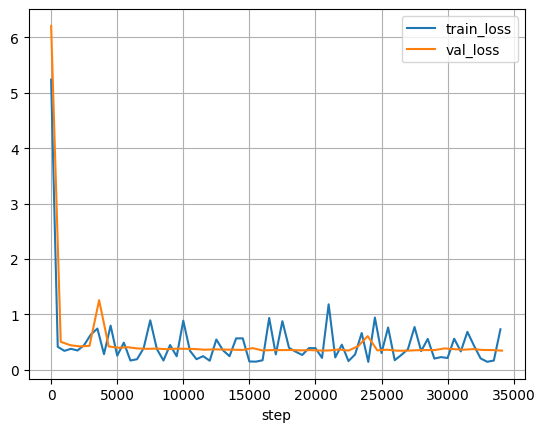

In [ ]:
# 绘制训练集与验证集的损失曲线，用于分析模型收敛情况和过拟合状态
# 注意：回归任务的损失值不一定在 [0,1] 范围内
def plot_learning_curves(record_dict, sample_step=500):
    """绘制训练过程中训练集和验证集的损失曲线
    参数:
        record_dict (dict): training() 函数返回的损失历史字典，含 'train' 和 'val' 两个键
        sample_step (int) : 训练集损失的采样间隔，避免绘制点过多导致图形密集；默认 500
    """
    # 将训练集损失记录转换为 DataFrame，以 step 为索引，每隔 sample_step 步取一个点
    train_df = pd.DataFrame(record_dict['train']).set_index('step').iloc[::sample_step]
    # 将验证集损失记录转换为 DataFrame，以 step 为索引（验证集记录较少，全部显示）
    val_df   = pd.DataFrame(record_dict['val']).set_index('step')

    for idx, item in enumerate(train_df.columns):   # 遍历每个指标列（本例只有 'loss'）
        plt.plot(train_df.index, train_df[item], label=f'train_{item}')  # 绘制训练集损失曲线
        plt.plot(val_df.index,   val_df[item],   label=f'val_{item}')    # 绘制验证集损失曲线
        plt.grid()    # 添加网格线，便于读数
        plt.legend()  # 显示图例
        plt.xlabel('step')  # 横坐标标签：全局步数
        plt.show()    # 展示图形

plot_learning_curves(record)  # 调用绘图函数，横坐标为全局步数（steps）

## 7. 测试集评估

In [ ]:
model.eval()  # 切换模型为评估模式（关闭 Dropout、固定 BatchNorm 统计量）
loss = evaluating(model, val_loader, loss_fct)  # 在验证集上计算平均 MSE 损失
print(f'loss:     {loss:.4f}')  # 打印格式化损失值，保留 4 位小数

loss:     0.3427
